# Import libraries : Load required libraries for data handling, visualization, preprocessing

In [168]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [169]:
df = pd.read_csv(r"C:\Users\MADHIVANAN\Downloads\netflix.csv")
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# Exploratory Data Analysis (EDA)   

In [170]:
df.shape

(8807, 12)

In [171]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [172]:
df.describe() #dataset From : 1925 - To   : 2021

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [173]:
print(f'Release Years \nFrom : {min(df['release_year'])} \nTo   : {max(df['release_year'])}')

Release Years 
From : 1925 
To   : 2021


In [174]:
df.duplicated().sum()

np.int64(0)

In [175]:
print(f"{df.isnull().sum()}\n===========================\npercentage : \n{df.isnull().sum()/len(df)*100}")
#if the column contain 1 - 2 percentage of null values we can remove it otherwise(greater than 2 percentage) we need to impute the null values


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64
percentage : 
show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64


In [176]:
print(df['type'].nunique())
print(df['type'].value_counts())

2
type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [177]:
for i in df.columns:
    print(f"{i} : {df[i].nunique()}")

show_id : 8807
type : 2
title : 8807
director : 4528
cast : 7692
country : 748
date_added : 1767
release_year : 74
rating : 17
duration : 220
listed_in : 514
description : 8775


In [178]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [179]:
rating_unique = df.groupby('rating').size().reset_index(name='count')
rating_unique

,rating,count
0,66 min,1
1,74 min,1
2,84 min,1
3,G,41
4,NC-17,3
5,NR,80
6,PG,287
7,PG-13,490
8,R,799
9,TV-14,2160


In [180]:
df[df['duration'].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


In [181]:
#'show_id'  = we don't need this column because it just a unique id's  
#'description' =  we don't need this column too because it a description about the show
#-----------------------------------------------------------------------------------------------
# No Duplicate rows
#-----------------------------------------------------------------------------------------------
#Null columns(missing values columns) ==> (missing values > 2 %) we need to impute the null values
#director        2634   (29.908028 %)         
#cast             825   (9.367549 %)
#country          831   (9.435676 %)
#date_added        10   (0.113546 %)       
#rating             4   (0.045418 %)    
#duration           3   (0.034064 %)
#------------------------------------------------------------------------------------------------
#'type'  = 2 categories --> Movie = 6131 , TV Show = 2676
#'title'  = unique title name = 8807
#'director'  = comma separated string (need to unnest) and missing values
#'cast'  = comma separated string (need to unnest) and missing values
#'country'  = comma separated string (need to unnest) and missing values
#'date_added'  = missing values
#'release_year'  = 1925 to 2021
#'rating'  = missing values
#'duration'  = missing values --- "duration" value mistakenly entered in "rating" 
#'listed_in'  = comma separated string (need to unnest)


In [182]:
#Why do we unnest a column?

# Pandas cannot properly analyse this, You cannot count directors, You cannot group by directors, 
# You cannot filter by directors, You cannot do machine learning using this column

We must unnest a column - 
Director column

In [183]:
un_nesting1 = df['director'].apply(lambda x: str(x).split(',')).tolist()    #now i chossing the director column
un_nesting1

[['Kirsten Johnson'],
 ['nan'],
 ['Julien Leclercq'],
 ['nan'],
 ['nan'],
 ['Mike Flanagan'],
 ['Robert Cullen', ' José Luis Ucha'],
 ['Haile Gerima'],
 ['Andy Devonshire'],
 ['Theodore Melfi'],
 ['nan'],
 ['Kongkiat Komesiri'],
 ['Christian Schwochow'],
 ['Bruno Garotti'],
 ['nan'],
 ['nan'],
 ['Pedro de Echave García', ' Pablo Azorín Williams'],
 ['nan'],
 ['Adam Salky'],
 ['nan'],
 ['Olivier Megaton'],
 ['nan'],
 ['K.S. Ravikumar'],
 ['Alex Woo', ' Stanley Moore'],
 ['S. Shankar'],
 ['nan'],
 ['Rajiv Menon'],
 ['Dennis Dugan'],
 ['Scott Stewart'],
 ['Robert Luketic'],
 ['Ashwiny Iyer Tiwari', ' Abhishek Chaubey', ' Saket Chaudhary'],
 ['nan'],
 ['nan'],
 ['nan'],
 ['nan'],
 ['Daniel Sandu'],
 ['Cédric Jimenez'],
 ['nan'],
 ['George Nolfi'],
 ['nan'],
 ['nan'],
 ['Steven Spielberg'],
 ['Jeannot Szwarc'],
 ['Joe Alves'],
 ['Joseph Sargent'],
 ['Tyler Greco'],
 ['Daniel Espinosa'],
 ['Bunmi Ajakaiye'],
 ['Antoine Fuqua'],
 ['nan'],
 ['nan'],
 ['Toshiya Shinohara'],
 ['Toshiya Shinohara

In [184]:
director_df = pd.DataFrame(un_nesting1, index= df['title'])
director_df.head(2)

,0,1,2,3,4,5,6,7,8,9,10,11,12
title,,,,,,,,,,,,,
Dick Johnson Is Dead,Kirsten Johnson,None,None,None,None,None,None,None,None,None,None,None,None
Blood & Water,nan,None,None,None,None,None,None,None,None,None,None,None,None


In [185]:
director_df = director_df.stack()
director_df.head(2)

title                  
Dick Johnson Is Dead  0    Kirsten Johnson
Blood & Water         0                nan
dtype: object

In [186]:
director_df = pd.DataFrame(director_df.reset_index()) # 'level_0': 'Title'|   'level_1: 0,1... | 0: 'Directors'
director_df.head(2)

,title,level_1,0
0,Dick Johnson Is Dead,0,Kirsten Johnson
1,Blood & Water,0,nan


In [187]:
director_df.rename(columns={0:'Directors'}, inplace=True )
director_df.head(2)

,title,level_1,Directors
0,Dick Johnson Is Dead,0,Kirsten Johnson
1,Blood & Water,0,nan


In [188]:
director_df.drop('level_1', axis=1, inplace=True)
director_df.head(5)

,title,Directors
0,Dick Johnson Is Dead,Kirsten Johnson
1,Blood & Water,nan
2,Ganglands,Julien Leclercq
3,Jailbirds New Orleans,nan
4,Kota Factory,nan


Cast column - Actors

In [189]:
un_nesting2 = df['cast'].apply(lambda x: str(x).split(',')).tolist()
cast_df = pd.DataFrame(un_nesting2, index= df['title'])
cast_df = cast_df.stack()
cast_df = pd.DataFrame(cast_df.reset_index())
cast_df.rename(columns={0: 'Actors'}, inplace=True)
cast_df.drop('level_1', axis=1, inplace=True)
cast_df.head(5)


,title,Actors
0,Dick Johnson Is Dead,nan
1,Blood & Water,Ama Qamata
2,Blood & Water,Khosi Ngema
3,Blood & Water,Gail Mabalane
4,Blood & Water,Thabang Molaba


listed_in column - TV_Categories

In [190]:
un_nesting3 = df['listed_in'].apply(lambda x: str(x).split(',')).tolist()
listed_in_df = pd.DataFrame(un_nesting3, index= df['title'])
listed_in_df = listed_in_df.stack()
listed_in_df = pd.DataFrame(listed_in_df.reset_index())
listed_in_df.rename(columns= {0: 'TV_Categories'}, inplace= True)
listed_in_df.drop('level_1', axis= 1, inplace=True)
listed_in_df.head()

,title,TV_Categories
0,Dick Johnson Is Dead,Documentaries
1,Blood & Water,International TV Shows
2,Blood & Water,TV Dramas
3,Blood & Water,TV Mysteries
4,Ganglands,Crime TV Shows


country column - Country

In [191]:
un_nesting4 = df['country']. apply(lambda x: str(x).split(',')).tolist()
country_df = pd.DataFrame(un_nesting4, index= df['title'])
country_df = country_df.stack()
country_df = pd.DataFrame(country_df.reset_index())
country_df.rename(columns={0: 'Country'}, inplace=True)
country_df.drop('level_1', axis=1, inplace=True)
country_df.head(5)

,title,Country
0,Dick Johnson Is Dead,United States
1,Blood & Water,South Africa
2,Ganglands,nan
3,Jailbirds New Orleans,nan
4,Kota Factory,India


Merging director and cast(Actors) dataframes on title

In [192]:
director_cast_df = pd.merge(director_df,cast_df,on= 'title' ,how='inner')
print(director_cast_df.shape)
director_cast_df.head(2)


(70812, 3)


,title,Directors,Actors
0,Dick Johnson Is Dead,Kirsten Johnson,nan
1,Blood & Water,nan,Ama Qamata


Merging director_cast and listed_in dataframes on title

In [193]:
director_cast_listed_in_df = pd.merge(director_cast_df, listed_in_df, on='title', how= 'inner')
print(director_cast_listed_in_df.shape)
director_cast_listed_in_df.head(2)

(161216, 4)


,title,Directors,Actors,TV_Categories
0,Dick Johnson Is Dead,Kirsten Johnson,nan,Documentaries
1,Blood & Water,nan,Ama Qamata,International TV Shows


Merging director_cast_listed_in and country dataframes on title

In [194]:
new_df = pd.merge(director_cast_listed_in_df, country_df, on='title', how= 'inner')
print(new_df.shape)
new_df.head(2)

(202065, 5)


,title,Directors,Actors,TV_Categories,Country
0,Dick Johnson Is Dead,Kirsten Johnson,nan,Documentaries,United States
1,Blood & Water,nan,Ama Qamata,International TV Shows,South Africa


Even though no null values(NaN) are shown but there are actually NaN present like nan so we need to change it


In [195]:
new_df.isna().sum() # now "nan" - its a string

title            0
Directors        0
Actors           0
TV_Categories    0
Country          0
dtype: int64

Replaces string "nan" in the DataFrame with proper NaN values

In [196]:
#replace is used to change any values into something else 
#fillna only work with NaN - missing values - its not work with "nan" because its string like "Hello"
new_df = new_df.replace("nan", np.nan)

In [197]:
new_df.isnull().sum()

title                0
Directors        50643
Actors            2149
TV_Categories        0
Country          11897
dtype: int64

Fills missing values in the Directors and Actors columns with Unknown Director and Unknown Actor

In [198]:
new_df['Directors'] = new_df['Directors'].fillna('Unknown Director')
new_df['Actors'] = new_df['Actors'].fillna('Unknown Actor')
#new_df['Country'] = new_df['Country'].fillna('Unknown Country') 


In [199]:
new_df.isnull().sum()

title                0
Directors            0
Actors               0
TV_Categories        0
Country          11897
dtype: int64

Merge new_df with selected columns from df on the title column, keeping all rows from new_df and adding matching data from df

In [200]:
final_df = pd.merge(new_df,df[['show_id', 'type', 'title', 'date_added','release_year', 'rating', 'duration']], on= 'title', how= 'left')
final_df.head(6)

,title,Directors,Actors,TV_Categories,Country,show_id,type,date_added,release_year,rating,duration
0,Dick Johnson Is Dead,Kirsten Johnson,Unknown Actor,Documentaries,United States,s1,Movie,"September 25, 2021",2020,PG-13,90 min
1,Blood & Water,Unknown Director,Ama Qamata,International TV Shows,South Africa,s2,TV Show,"September 24, 2021",2021,TV-MA,2 Seasons
2,Blood & Water,Unknown Director,Ama Qamata,TV Dramas,South Africa,s2,TV Show,"September 24, 2021",2021,TV-MA,2 Seasons
3,Blood & Water,Unknown Director,Ama Qamata,TV Mysteries,South Africa,s2,TV Show,"September 24, 2021",2021,TV-MA,2 Seasons
4,Blood & Water,Unknown Director,Khosi Ngema,International TV Shows,South Africa,s2,TV Show,"September 24, 2021",2021,TV-MA,2 Seasons
5,Blood & Water,Unknown Director,Khosi Ngema,TV Dramas,South Africa,s2,TV Show,"September 24, 2021",2021,TV-MA,2 Seasons


In [201]:
print(f"df : {df.shape}\nfinal_df : {final_df.shape}")
print(f"title column is unique: {df['title'].nunique()}") 
#title is unique in df so if we do the left join on df(8807, 12) and finall_df(202065, 11),it duplicate the rows, so it won't create new null
# but i already have nulls in df and they get duplicated

df : (8807, 12)
final_df : (202065, 11)
title column is unique: 8807


In [202]:
final_df.isnull().sum() #which rows have missing duration

title                0
Directors            0
Actors               0
TV_Categories        0
Country          11897
show_id              0
type                 0
date_added         158
release_year         0
rating              67
duration             3
dtype: int64

In [203]:
#it Gives duration column, but only for the rows where duration is missing
#final_df.loc[final_df['duration'].isnull()]
final_df.loc[final_df['duration'].isnull(),'duration']


126582    NaN
131648    NaN
131782    NaN
Name: duration, dtype: object

Replace the missing duration with the value from the rating column

In [204]:
final_df.loc[final_df['duration'].isnull(),'duration'] = final_df.loc[final_df['duration'].isnull(),'duration'].fillna(final_df['rating'])  
#                       NUll Values Rows                                      NUll Values Rows                  filled by same rating rows             

Rating values that incorrectly contain "min" and replaces them with NR

In [205]:
print(final_df.loc[final_df['rating'].str.contains('min',na=False), 'rating'])  #This checks each value in the rating column, if its not 'min' it show false,
#na= False => treat NaN values as false
final_df.loc[final_df['rating'].str.contains('min',na=False), 'rating'] = 'NR'
print(final_df.loc[final_df['rating'].str.contains('min',na=False), 'rating'])

126582    74 min
131648    84 min
131782    66 min
Name: rating, dtype: object
Series([], Name: rating, dtype: object)


Fills all missing NaN values in the rating column with NR - Not Rated

In [206]:
final_df['rating'] = final_df['rating'].fillna('NR')

In [207]:
final_df.isnull().sum()

title                0
Directors            0
Actors               0
TV_Categories        0
Country          11897
show_id              0
type                 0
date_added         158
release_year         0
rating               0
duration             0
dtype: int64

Fills missing date_added values with the most common mode - date_added for the same release_year

In [208]:
date_added_null_years = final_df[final_df['date_added'].isnull()]['release_year'].unique()
for i in date_added_null_years:
    date_imp = final_df[final_df['release_year'] == i]['date_added'].mode().values[0]
    final_df.loc[final_df['release_year'] == i, 'date_added'] = final_df.loc[final_df['release_year'] == i, 'date_added'].fillna(date_imp)


Replaces empty strings in the Country column with proper NaN values

In [209]:
final_df['Country'].replace([''],[np.nan],inplace=True)

C:\Users\MADHIVANAN\AppData\Local\Temp\ipykernel_10932\1375855126.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  final_df['Country'].replace([''],[np.nan],inplace=True)


In [210]:
final_df.isnull().sum()

title                0
Directors            0
Actors               0
TV_Categories        0
Country          12003
show_id              0
type                 0
date_added           0
release_year         0
rating               0
duration             0
dtype: int64

Fills missing Country values by using the most common (mode) country for each director, if that director appears in other rows with a known country

In [211]:
Country_null_Directors = final_df[final_df['Country'].isnull()]['Directors'].unique()
for i in Country_null_Directors:
    if i in final_df[final_df['Country'].notnull()]['Directors'].unique():
        country_imp = final_df[final_df['Directors'] == i]['Country'].mode().values[0]
        final_df.loc[final_df['Directors']== i, 'Country'] = final_df.loc[final_df['Directors']== i, 'Country'].fillna(country_imp)


Fills missing Country values using the most frequent (mode) country for each actor, if that actor appears elsewhere with a known country

In [212]:
Country_null_Actors = final_df[final_df['Country'].isnull()]['Actors'].unique()
for i in Country_null_Actors:
    if i in final_df[final_df['Country'].notnull()]['Actors'].unique():
        country_impu= final_df[final_df['Actors']==i]['Country'].mode().values[0]
        final_df.loc[final_df['Actors']==i, 'Country'] = final_df.loc[final_df['Actors']==i, 'Country'].fillna(country_impu)

In [213]:
final_df['Country'].isnull().sum()

np.int64(2455)

Fills missing values in the balance Country columns NaN with Unknown country

In [214]:
final_df['Country']= final_df['Country'].fillna("Unknown country")

In [215]:
final_df.isna().sum()

title            0
Directors        0
Actors           0
TV_Categories    0
Country          0
show_id          0
type             0
date_added       0
release_year     0
rating           0
duration         0
dtype: int64

In [216]:
#final_df.to_csv(r"C:\Users\MADHIVANAN\OneDrive\Desktop\Python Tut\visionary Ascent Projects\netflix_otpo.csv",index=False)

Creates a copy of final_df named final_df_copy to preserve the original data for safe analysis or manipulation.

In [217]:
final_df_copy = final_df.copy()

In [218]:
final_df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202065 entries, 0 to 202064
Data columns (total 11 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   title          202065 non-null  object
 1   Directors      202065 non-null  object
 2   Actors         202065 non-null  object
 3   TV_Categories  202065 non-null  object
 4   Country        202065 non-null  object
 5   show_id        202065 non-null  object
 6   type           202065 non-null  object
 7   date_added     202065 non-null  object
 8   release_year   202065 non-null  int64 
 9   rating         202065 non-null  object
 10  duration       202065 non-null  object
dtypes: int64(1), object(10)
memory usage: 17.0+ MB


In [219]:
for d in final_df.columns:
    print(f"{d} : {final_df[d].nunique()}")

title : 8807
Directors : 5121
Actors : 39297
TV_Categories : 73
Country : 197
show_id : 8807
type : 2
date_added : 1767
release_year : 74
rating : 14
duration : 220


Prints the number of unique values in each column and removes extra spaces from text for data cleaning

In [220]:
for i in final_df_copy.columns:
    print(f"{i} : {final_df_copy[i].nunique()}")
    if final_df_copy[i].dtype == 'object':
        final_df_copy[i] = final_df_copy[i].str.strip()

title : 8807
Directors : 5121
Actors : 39297
TV_Categories : 73
Country : 197
show_id : 8807
type : 2
date_added : 1767
release_year : 74
rating : 14
duration : 220


Replaces duration values containing "Seasons" with 0, converting season info into a numeric values

In [221]:
final_df_copy.loc[final_df_copy['duration'].str.contains('Seasons'), 'duration'] = 0 

In [222]:
final_df_copy.head(10)

,title,Directors,Actors,TV_Categories,Country,show_id,type,date_added,release_year,rating,duration
0,Dick Johnson Is Dead,Kirsten Johnson,Unknown Actor,Documentaries,United States,s1,Movie,"September 25, 2021",2020,PG-13,90 min
1,Blood & Water,Unknown Director,Ama Qamata,International TV Shows,South Africa,s2,TV Show,"September 24, 2021",2021,TV-MA,0
2,Blood & Water,Unknown Director,Ama Qamata,TV Dramas,South Africa,s2,TV Show,"September 24, 2021",2021,TV-MA,0
3,Blood & Water,Unknown Director,Ama Qamata,TV Mysteries,South Africa,s2,TV Show,"September 24, 2021",2021,TV-MA,0
4,Blood & Water,Unknown Director,Khosi Ngema,International TV Shows,South Africa,s2,TV Show,"September 24, 2021",2021,TV-MA,0
5,Blood & Water,Unknown Director,Khosi Ngema,TV Dramas,South Africa,s2,TV Show,"September 24, 2021",2021,TV-MA,0
6,Blood & Water,Unknown Director,Khosi Ngema,TV Mysteries,South Africa,s2,TV Show,"September 24, 2021",2021,TV-MA,0
7,Blood & Water,Unknown Director,Gail Mabalane,International TV Shows,South Africa,s2,TV Show,"September 24, 2021",2021,TV-MA,0
8,Blood & Water,Unknown Director,Gail Mabalane,TV Dramas,South Africa,s2,TV Show,"September 24, 2021",2021,TV-MA,0
9,Blood & Water,Unknown Director,Gail Mabalane,TV Mysteries,South Africa,s2,TV Show,"September 24, 2021",2021,TV-MA,0


In [223]:
final_df_copy.tail(10)

,title,Directors,Actors,TV_Categories,Country,show_id,type,date_added,release_year,rating,duration
202055,Zubaan,Mozez Singh,Meghna Malik,Music & Musicals,India,s8807,Movie,"March 2, 2019",2015,TV-14,111 min
202056,Zubaan,Mozez Singh,Malkeet Rauni,Dramas,India,s8807,Movie,"March 2, 2019",2015,TV-14,111 min
202057,Zubaan,Mozez Singh,Malkeet Rauni,International Movies,India,s8807,Movie,"March 2, 2019",2015,TV-14,111 min
202058,Zubaan,Mozez Singh,Malkeet Rauni,Music & Musicals,India,s8807,Movie,"March 2, 2019",2015,TV-14,111 min
202059,Zubaan,Mozez Singh,Anita Shabdish,Dramas,India,s8807,Movie,"March 2, 2019",2015,TV-14,111 min
202060,Zubaan,Mozez Singh,Anita Shabdish,International Movies,India,s8807,Movie,"March 2, 2019",2015,TV-14,111 min
202061,Zubaan,Mozez Singh,Anita Shabdish,Music & Musicals,India,s8807,Movie,"March 2, 2019",2015,TV-14,111 min
202062,Zubaan,Mozez Singh,Chittaranjan Tripathy,Dramas,India,s8807,Movie,"March 2, 2019",2015,TV-14,111 min
202063,Zubaan,Mozez Singh,Chittaranjan Tripathy,International Movies,India,s8807,Movie,"March 2, 2019",2015,TV-14,111 min
202064,Zubaan,Mozez Singh,Chittaranjan Tripathy,Music & Musicals,India,s8807,Movie,"March 2, 2019",2015,TV-14,111 min


In [224]:
df.shape

(8807, 12)

In [225]:
final_df.shape

(202065, 11)

# Data Analysis

## Questions to be Explored Now for Recommendations

1)So this time, the granularity level is country  and analysis of TV Shows/Movies the country brings. I am going to consider only the top countries individually for TV Shows and Movies. There are definitely some common countries too which bring out quality content in both TV Shows and Movies.

2)Which Genres do these countries offer and what are the intended audiences(Ratings) which are popular in Netflix?

3)In case of Movies, what is the duration/length of movies which makes them special and depicts attention span?

4)Who are the popular actors/directors across TV Shows and Movies in these countries?

5)In what time of the year, people tend to watch movies and shows in these countries?

6)Popular Actor and Director Combinations in these countries

## 1. Top countries individually for TV Shows and Movies. There are definitely some common countries too which bring out quality content in both TV Shows and Movies.

type
Movie      145917
TV Show     56148
Name: count, dtype: int64


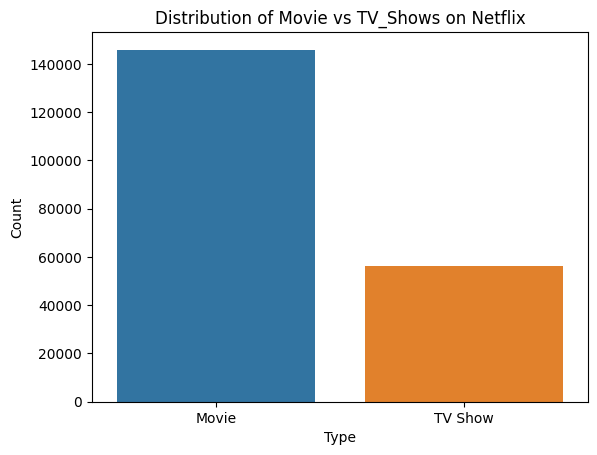

In [226]:
print(final_df_copy['type'].value_counts())
sns.countplot(x="type",hue='type', data=final_df_copy)
plt.title("Distribution of Movie vs TV_Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

In [227]:
top_movie_countries = final_df[final_df_copy['type'] == 'Movie'].groupby('Country').size().sort_values(ascending=False)
top_Tv_shows_countries = final_df[final_df_copy['type'] == 'TV Show'].groupby('Country').size().sort_values(ascending=False)

In [228]:
top_movie_countries = top_movie_countries.head(10)
top_Tv_shows_countries = top_Tv_shows_countries.head(10)

In [229]:
top_movie_countries_df = top_movie_countries.reset_index(name= 'Movie_count')
top_Tv_shows_countries_df = top_Tv_shows_countries.reset_index(name='TV_Shows_Count')

In [230]:
common_countries = set(top_movie_countries_df['Country']) & set(top_Tv_shows_countries_df['Country'])
common_countries

{' United States',
 'Canada',
 'India',
 'Japan',
 'United Kingdom',
 'United States'}

In [231]:
merge_movie_tv_show = pd.merge(top_movie_countries_df,top_Tv_shows_countries_df, on='Country', how='inner')
merge_movie_tv_show

,Country,Movie_count,TV_Shows_Count
0,United States,39378,16306
1,India,21706,1496
2,United States,7540,1981
3,United Kingdom,5741,4081
4,Japan,2997,4683
5,Canada,2940,1467


In [232]:
merge_movie_tv_show['Movie_TV_show_ratio'] = merge_movie_tv_show['Movie_count']/merge_movie_tv_show['TV_Shows_Count']
merge_movie_tv_show # > 1 - movie dominate country ; < 1 - TV_show dominate country

,Country,Movie_count,TV_Shows_Count,Movie_TV_show_ratio
0,United States,39378,16306,2.414939
1,India,21706,1496,14.509358
2,United States,7540,1981,3.806159
3,United Kingdom,5741,4081,1.406763
4,Japan,2997,4683,0.639974
5,Canada,2940,1467,2.004090


### Insights:  
             United States and India dominate the Netflix content in both movies and TV_shows
             Movies significantly outperform TV shows in overall content dominance and audience consumption
### Recommendation: 
             Focus investment and promotions on movies, as they attract higher audience engagement than TV shows

## 2. Which Genres do these countries offer and what are the intended audiences(Ratings) which are popular in Netflix?

In [233]:
print(final_df_copy['Country'].value_counts())
print(f"\n No of unique countries: {final_df_copy['Country'].nunique()}")

Country
United States     65205
India             23877
United Kingdom    13057
Japan              9045
France             8450
                  ...  
Botswana              2
Afghanistan           2
Nicaragua             1
Kazakhstan            1
Uganda                1
Name: count, Length: 123, dtype: int64

 No of unique countries: 123


TV-MA = Focuses on adult audiences (18+) and TV-14 = Focuses on teen audiences (14+)

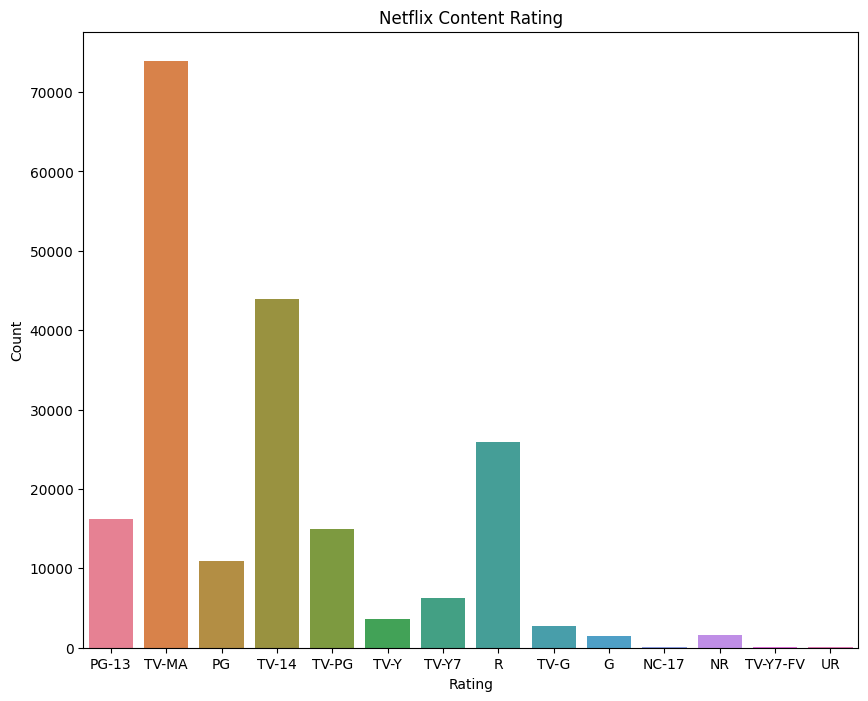

In [234]:
plt.figure(figsize=(10,8))
sns.countplot(x="rating",hue='rating', data=final_df_copy)
plt.title("Netflix Content Rating")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [235]:

Country_TV_Categories = final_df_copy.groupby(['Country', 'TV_Categories']).size().reset_index(name='count').sort_values('count',ascending= False)
Country_TV_Categories.head(5)


,Country,TV_Categories,count
1352,United States,Comedies,8544
1357,United States,Dramas,8214
529,India,International Movies,7254
525,India,Dramas,5723
1349,United States,Children & Family Movies,5215


In [236]:
Country_Rating = final_df_copy.groupby(['Country','rating']).size().reset_index(name='count').sort_values('count',ascending=False)
Country_Rating.head(5)

,Country,rating,count
491,United States,TV-MA,17315
488,United States,R,13542
195,India,TV-14,12775
487,United States,PG-13,9209
489,United States,TV-14,7788


In [237]:
Country_TV_Categories_Rating = final_df_copy.groupby(['Country', 'TV_Categories', 'rating']).size().reset_index(name='count').sort_values('count',ascending=False)
Country_TV_Categories_Rating.head(10)

,Country,TV_Categories,rating,count
1318,India,International Movies,TV-14,4198
1295,India,Dramas,TV-14,3166
3263,United States,Dramas,R,3161
3199,United States,Children & Family Movies,PG,2219
3226,United States,Comedies,R,2186
3176,United States,Action & Adventure,R,1893
1320,India,International Movies,TV-MA,1878
3407,United States,TV Dramas,TV-MA,1848
3224,United States,Comedies,PG,1733
3225,United States,Comedies,PG-13,1698


In [238]:
top_genre_rating = Country_TV_Categories_Rating.groupby('Country').head(1)


In [239]:
top_country_rating_simple = Country_Rating[['Country', 'rating', 'count']]
top_country_rating_simple.head(50)


,Country,rating,count
491,United States,TV-MA,17315
488,United States,R,13542
195,India,TV-14,12775
487,United States,PG-13,9209
489,United States,TV-14,7788
197,India,TV-MA,6572
486,United States,PG,6055
478,United Kingdom,TV-MA,4417
422,Spain,TV-MA,4404
148,France,TV-MA,4030


### Insights: 
             TV-MA and TV-14 are the most dominant ratings across Netflix, indicating a strong focus on adult and teen audiences globally.
             The United States dominates adult-oriented comedy and drama, India focuses on international and teen-rated content, while smaller countries contribute niche adult-focused dramas and documentaries 
### Recommendations:
             Prioritize TV-MA content production and acquisition, especially for the United States and European region.
             Expand TV-14 content strategically in high-growth regions like India and parts of Asia.

## 3. In case of Movies, what is the duration/length of movies which makes them special and depicts attention span?

In [240]:
movie_df = final_df_copy[final_df_copy['type'] == 'Movie'].copy()
movie_df.head()

,title,Directors,Actors,TV_Categories,Country,show_id,type,date_added,release_year,rating,duration
0,Dick Johnson Is Dead,Kirsten Johnson,Unknown Actor,Documentaries,United States,s1,Movie,"September 25, 2021",2020,PG-13,90 min
159,My Little Pony: A New Generation,Robert Cullen,Vanessa Hudgens,Children & Family Movies,United States,s7,Movie,"September 24, 2021",2021,PG,91 min
160,My Little Pony: A New Generation,Robert Cullen,Kimiko Glenn,Children & Family Movies,United States,s7,Movie,"September 24, 2021",2021,PG,91 min
161,My Little Pony: A New Generation,Robert Cullen,James Marsden,Children & Family Movies,United States,s7,Movie,"September 24, 2021",2021,PG,91 min
162,My Little Pony: A New Generation,Robert Cullen,Sofia Carson,Children & Family Movies,Argentina,s7,Movie,"September 24, 2021",2021,PG,91 min


In [241]:
movie_df.shape

(145917, 11)

In [242]:
#movie_df['duration'] = movie_df['duration'].str.split(' ').str[0]
movie_df['duration'] = movie_df['duration'].str.replace('min','').astype(int)
movie_df.head()

,title,Directors,Actors,TV_Categories,Country,show_id,type,date_added,release_year,rating,duration
0,Dick Johnson Is Dead,Kirsten Johnson,Unknown Actor,Documentaries,United States,s1,Movie,"September 25, 2021",2020,PG-13,90
159,My Little Pony: A New Generation,Robert Cullen,Vanessa Hudgens,Children & Family Movies,United States,s7,Movie,"September 24, 2021",2021,PG,91
160,My Little Pony: A New Generation,Robert Cullen,Kimiko Glenn,Children & Family Movies,United States,s7,Movie,"September 24, 2021",2021,PG,91
161,My Little Pony: A New Generation,Robert Cullen,James Marsden,Children & Family Movies,United States,s7,Movie,"September 24, 2021",2021,PG,91
162,My Little Pony: A New Generation,Robert Cullen,Sofia Carson,Children & Family Movies,Argentina,s7,Movie,"September 24, 2021",2021,PG,91


In [243]:
movie_df['duration'].describe()

count    145917.000000
mean        106.839724
std          24.709594
min           3.000000
25%          93.000000
50%         104.000000
75%         119.000000
max         312.000000
Name: duration, dtype: float64

In [244]:
top_duration = movie_df['duration'].value_counts().sort_values(ascending= False)
top_duration.head(10)

duration
94     4343
106    4040
97     3624
95     3560
96     3511
93     3480
90     3305
105    3209
107    3103
101    3048
Name: count, dtype: int64

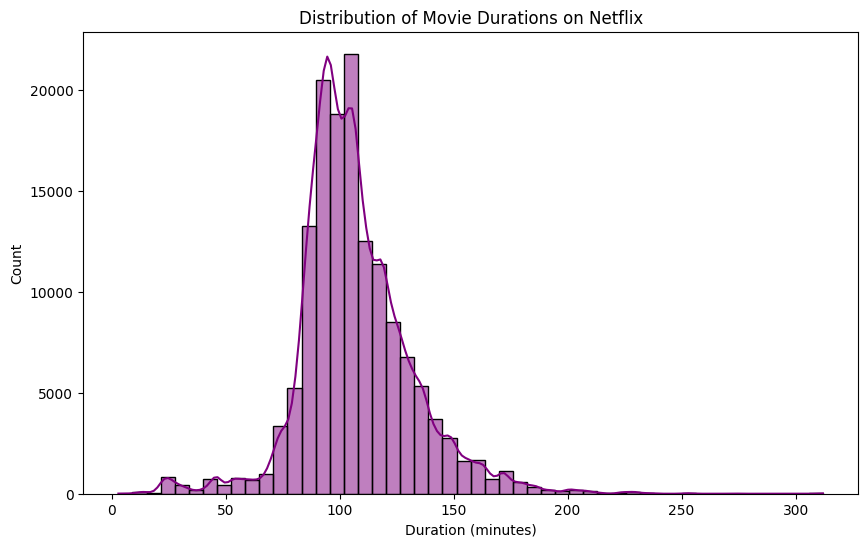

In [245]:
plt.figure(figsize=(10,6))
sns.histplot(movie_df['duration'], bins=50, kde=True, color='purple')
plt.title("Distribution of Movie Durations on Netflix")
plt.xlabel("Duration (minutes)")
plt.ylabel("Count")
plt.show()


### Insights: 
             Movies with a 90–110 minute runtime perform best because they align well with audience attention span and viewing comfort.
### Recommendation: 
             Prioritize producing and promoting movies within the 90–110 minute range to maximize viewer engagement and completion rates.

## 4. Who are the popular actors/directors across TV Shows and Movies in these countries?

In [246]:
cleaned_Actor_name = final_df_copy[final_df_copy['Actors'] != 'Unknown Actor']
cleaned_Actor_name.head(10)

,title,Directors,Actors,TV_Categories,Country,show_id,type,date_added,release_year,rating,duration
1,Blood & Water,Unknown Director,Ama Qamata,International TV Shows,South Africa,s2,TV Show,"September 24, 2021",2021,TV-MA,0
2,Blood & Water,Unknown Director,Ama Qamata,TV Dramas,South Africa,s2,TV Show,"September 24, 2021",2021,TV-MA,0
3,Blood & Water,Unknown Director,Ama Qamata,TV Mysteries,South Africa,s2,TV Show,"September 24, 2021",2021,TV-MA,0
4,Blood & Water,Unknown Director,Khosi Ngema,International TV Shows,South Africa,s2,TV Show,"September 24, 2021",2021,TV-MA,0
5,Blood & Water,Unknown Director,Khosi Ngema,TV Dramas,South Africa,s2,TV Show,"September 24, 2021",2021,TV-MA,0
6,Blood & Water,Unknown Director,Khosi Ngema,TV Mysteries,South Africa,s2,TV Show,"September 24, 2021",2021,TV-MA,0
7,Blood & Water,Unknown Director,Gail Mabalane,International TV Shows,South Africa,s2,TV Show,"September 24, 2021",2021,TV-MA,0
8,Blood & Water,Unknown Director,Gail Mabalane,TV Dramas,South Africa,s2,TV Show,"September 24, 2021",2021,TV-MA,0
9,Blood & Water,Unknown Director,Gail Mabalane,TV Mysteries,South Africa,s2,TV Show,"September 24, 2021",2021,TV-MA,0
10,Blood & Water,Unknown Director,Thabang Molaba,International TV Shows,South Africa,s2,TV Show,"September 24, 2021",2021,TV-MA,0


In [247]:
top_Actors_country = cleaned_Actor_name.groupby(['Country','Actors']).size().reset_index(name= 'count').sort_values('count',ascending=False)
top_Actors_country.head(20)

,Country,Actors,count
14335,India,Anupam Kher,113
17017,India,Shah Rukh Khan,99
16005,India,Naseeruddin Shah,98
14098,India,Akshay Kumar,87
16430,India,Radhika Apte,86
16208,India,Paresh Rawal,85
14171,India,Amitabh Bachchan,85
21374,Japan,Yuki Kaji,83
16155,India,Om Puri,79
21118,Japan,Takahiro Sakurai,78


### Insights: 
             Indian actors dominate the list, indicating strong content volume and audience preference for Indian cinema across Movies and TV Shows.
                 Anupam Kher, Shah Rukh Khan, Naseeruddin Shah, Akshay Kumar, Amitabh Bachchan appear more frequently, highlighting demand for performance-driven roles
             Japanese voice actors highlight the popularity of anime content
                 Yuki Kaji, Takahiro Sakurai, Daisuke Ono appear more frequently.

In [248]:
cleaned_Directors_name = final_df_copy[final_df_copy['Directors'] != 'Unknown Director']
cleaned_Directors_name.head(10)

,title,Directors,Actors,TV_Categories,Country,show_id,type,date_added,release_year,rating,duration
0,Dick Johnson Is Dead,Kirsten Johnson,Unknown Actor,Documentaries,United States,s1,Movie,"September 25, 2021",2020,PG-13,90 min
58,Ganglands,Julien Leclercq,Sami Bouajila,Crime TV Shows,France,s3,TV Show,"September 24, 2021",2021,TV-MA,1 Season
59,Ganglands,Julien Leclercq,Sami Bouajila,International TV Shows,France,s3,TV Show,"September 24, 2021",2021,TV-MA,1 Season
60,Ganglands,Julien Leclercq,Sami Bouajila,TV Action & Adventure,France,s3,TV Show,"September 24, 2021",2021,TV-MA,1 Season
61,Ganglands,Julien Leclercq,Tracy Gotoas,Crime TV Shows,France,s3,TV Show,"September 24, 2021",2021,TV-MA,1 Season
62,Ganglands,Julien Leclercq,Tracy Gotoas,International TV Shows,France,s3,TV Show,"September 24, 2021",2021,TV-MA,1 Season
63,Ganglands,Julien Leclercq,Tracy Gotoas,TV Action & Adventure,France,s3,TV Show,"September 24, 2021",2021,TV-MA,1 Season
64,Ganglands,Julien Leclercq,Samuel Jouy,Crime TV Shows,France,s3,TV Show,"September 24, 2021",2021,TV-MA,1 Season
65,Ganglands,Julien Leclercq,Samuel Jouy,International TV Shows,France,s3,TV Show,"September 24, 2021",2021,TV-MA,1 Season
66,Ganglands,Julien Leclercq,Samuel Jouy,TV Action & Adventure,France,s3,TV Show,"September 24, 2021",2021,TV-MA,1 Season


In [249]:
top_Directors_country = cleaned_Directors_name.groupby(['Country','Directors']).size().reset_index(name='count').sort_values('count',ascending=False)
top_Directors_country.head(50)

,Country,Directors,count
3239,Philippines,Cathy Garcia-Molina,356
1035,Egypt,Youssef Chahine,288
6002,United States,Martin Scorsese,273
1857,India,David Dhawan,270
6687,United States,Steven Spielberg,243
3927,Turkey,Yılmaz Erdoğan,227
3133,Nigeria,Kunle Afolayan,223
1784,India,Anurag Kashyap,219
2796,Japan,Toshiya Shinohara,204
3257,Philippines,Mae Czarina Cruz,198


### Insights: 
             Indian and United States directors dominate, showing high content production from these regions
             Philippines and Egypt stand out with top individual directors
             Japan and Nigeria have consistent representation, reflecting steady regional content demand

## 5. In what time of the year, people tend to watch movies and shows in these countries?

In [250]:
final_df_copy['date_added'] = pd.to_datetime(final_df_copy['date_added'])
final_df_copy['Month'] = final_df_copy['date_added'].dt.month

In [251]:
monthly_views = final_df_copy.groupby(['Country','Month']).size().reset_index(name='count').sort_values(by= 'count',ascending=False)

In [252]:
final_df_copy['Month'].value_counts().sort_values(ascending=False)

Month
7     20384
12    18266
1     18254
9     18144
10    17796
8     17110
4     17108
6     16659
3     15859
11    15598
5     13827
2     13060
Name: count, dtype: int64

### Insights: 
             The peak months for viewing content are July, December, January, September, and October which aligns with school holidays, summer, and winter festive seasons
### Recommendation: 
             Schedule major content releases and promotions in high activity months (July, December, and January), while using low activity months (February and May) for targeted launches, testing new content

## 6. Popular Actor and Director Combinations in these countries

In [253]:
cleaned_Actor_Director_name = final_df_copy[(final_df_copy['Actors'] != 'Unknown Actor') & (final_df_copy['Directors'] != 'Unknown Director')]
cleaned_Actor_Director_name.head(50)

,title,Directors,Actors,TV_Categories,Country,show_id,type,date_added,release_year,rating,duration,Month
58,Ganglands,Julien Leclercq,Sami Bouajila,Crime TV Shows,France,s3,TV Show,2021-09-24,2021,TV-MA,1 Season,9
59,Ganglands,Julien Leclercq,Sami Bouajila,International TV Shows,France,s3,TV Show,2021-09-24,2021,TV-MA,1 Season,9
60,Ganglands,Julien Leclercq,Sami Bouajila,TV Action & Adventure,France,s3,TV Show,2021-09-24,2021,TV-MA,1 Season,9
61,Ganglands,Julien Leclercq,Tracy Gotoas,Crime TV Shows,France,s3,TV Show,2021-09-24,2021,TV-MA,1 Season,9
62,Ganglands,Julien Leclercq,Tracy Gotoas,International TV Shows,France,s3,TV Show,2021-09-24,2021,TV-MA,1 Season,9
63,Ganglands,Julien Leclercq,Tracy Gotoas,TV Action & Adventure,France,s3,TV Show,2021-09-24,2021,TV-MA,1 Season,9
64,Ganglands,Julien Leclercq,Samuel Jouy,Crime TV Shows,France,s3,TV Show,2021-09-24,2021,TV-MA,1 Season,9
65,Ganglands,Julien Leclercq,Samuel Jouy,International TV Shows,France,s3,TV Show,2021-09-24,2021,TV-MA,1 Season,9
66,Ganglands,Julien Leclercq,Samuel Jouy,TV Action & Adventure,France,s3,TV Show,2021-09-24,2021,TV-MA,1 Season,9
67,Ganglands,Julien Leclercq,Nabiha Akkari,Crime TV Shows,France,s3,TV Show,2021-09-24,2021,TV-MA,1 Season,9


In [254]:
Popular_actor_director_combo = cleaned_Actor_Director_name.groupby(['Country', 'Directors','Actors']).size().reset_index(name='count').sort_values('count',ascending=False)
Popular_actor_director_combo.head(50)

,Country,Directors,Actors,count
19495,India,S.S. Rajamouli,Anushka Shetty,21
19503,India,S.S. Rajamouli,Tamannaah Bhatia,21
19499,India,S.S. Rajamouli,Rana Daggubati,21
19500,India,S.S. Rajamouli,Sathyaraj,21
19497,India,S.S. Rajamouli,Prabhas,21
19498,India,S.S. Rajamouli,Ramya Krishnan,21
24882,Japan,Toshiya Shinohara,Satsuki Yukino,21
24875,Japan,Toshiya Shinohara,Kumiko Watanabe,21
24868,Japan,Toshiya Shinohara,Houko Kuwashima,21
24874,Japan,Toshiya Shinohara,Koji Tsujitani,21


### Insights:
             India: S.S. Rajamouli consistently works with the same star cast, indicating director-driven blockbuster collaborations
             Japan: Toshiya Shinohara consistently works with Animation and voice acting ecosystems show higher repetition
### Recommendation: 
             Keep working with popular director_actor teams, like S.S. Rajamouli and his cast, to attract viewers.